# Example queries — main_survey_database_v2

Database: `/scratch/duckdb-database/main_survey_database_v2.duckdb`

Schema (5-level hierarchy):
- `patients` → `brain_regions` → `cell_types` → `cells` → `oligomers`

Key columns:
- `cells.oligomer_concentration_per_um3` = `n_puncta_in_cell / area_um3` (oligomers µm⁻³)
- `oligomers.in_cell` — TRUE for in-cell oligomers (15.2 M rows), FALSE for out-of-cell (315 M rows)
- `oligomers.sum_intensity_in_photons` — individual oligomer brightness; use to re-compute higher-percentile thresholds

**Scaling convention used in plots:** multiply `oligomer_concentration_per_um3` by a reference sphere volume (4π/3 × 5³ ≈ 524 µm³) to get oligomers per reference sphere — matching the previous flat-table plotting convention.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

DB_PATH = "/scratch/duckdb-database/main_survey_database_v2.duckdb"

# Reference sphere of radius 5 µm — scaling factor for display (not stored in DB)
REF_VOL_UM3 = (4 * np.pi / 3) * 5**3  # ≈ 524 µm³

conn = duckdb.connect(DB_PATH, read_only=True)

# Quick sanity check
for tbl in ("patients", "cells", "oligomers"):
    n = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"{tbl:12s}: {n:>12,}")

patients    :           27
cells       :      508,213
oligomers   :  330,456,267


## 1. Load cell-level data with patient metadata

In [2]:
df = conn.execute("""
    SELECT
        c.patient_id,
        c.brain_region,
        c.cell_type,
        c.n_puncta_in_cell,
        c.area_um3,
        c.oligomer_concentration_per_um3,
        p.condition,
        p.sex,
        p.age_at_death
    FROM cells c
    JOIN patients p ON c.patient_id = p.patient_id
    WHERE c.oligomer_concentration_per_um3 IS NOT NULL
""").df()

df["oligos_per_ref_vol"] = df["oligomer_concentration_per_um3"] * REF_VOL_UM3

print(f"{len(df):,} cells loaded")
print(f"Regions:    {sorted(df['brain_region'].unique())}")
print(f"Cell types: {sorted(df['cell_type'].unique())}")
df.head(3)

508,213 cells loaded
Regions:    ['caudate', 'cingulate', 'frontal', 'parahippocampal', 'parietal', 'putamen', 'substantiaNigra', 'temporal']
Cell types: ['astrocytes', 'microglia', 'neurons']


,patient_id,brain_region,cell_type,n_puncta_in_cell,area_um3,oligomer_concentration_per_um3,condition,sex,age_at_death,oligos_per_ref_vol
0,PD12,temporal,neurons,0,12.49325,0.0,PD,M,73,0.0
1,PD12,temporal,neurons,0,19.06960,0.0,PD,M,73,0.0
2,PD12,temporal,neurons,0,16.86135,0.0,PD,M,73,0.0


## 2. Histogram of oligomer concentration by brain region

KDE on log scale — concentrations are right-skewed. Cells with zero oligomers (n_puncta_in_cell = 0) are shown separately as a fraction.

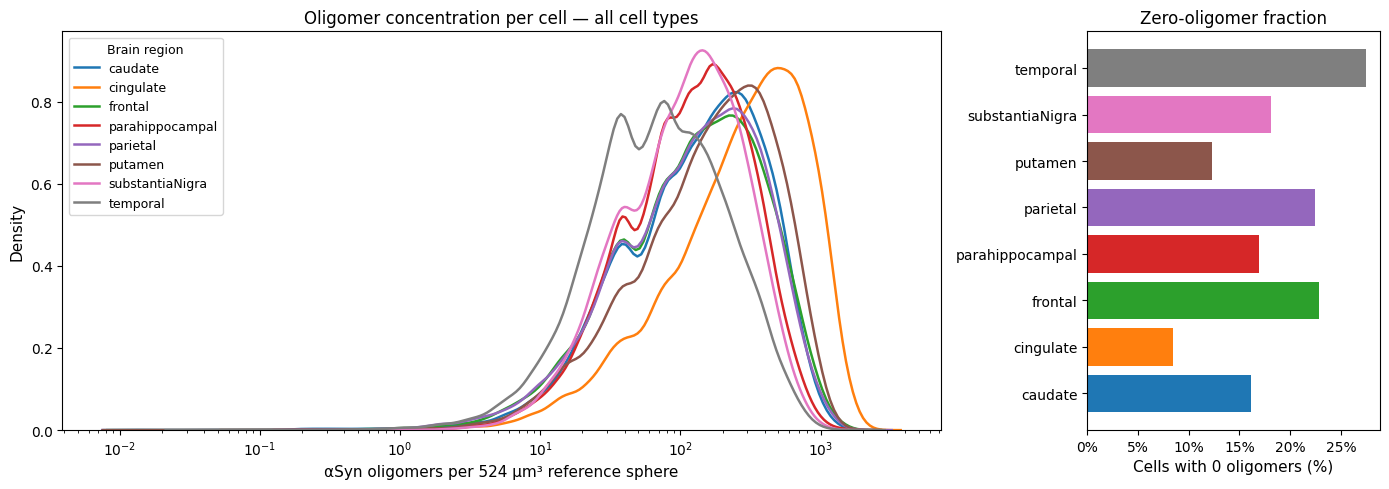

In [3]:
regions = sorted(df["brain_region"].unique())
palette = dict(zip(regions, sns.color_palette("tab10", n_colors=len(regions))))

df_nonzero = df[df["oligos_per_ref_vol"] > 0].copy()

# --- fraction of zero-oligomer cells per region (shown as text) ---
zero_frac = (
    df.groupby("brain_region")
    .apply(lambda g: (g["n_puncta_in_cell"] == 0).mean(), include_groups=False)
    .rename("zero_frac")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

# KDE plot
ax = axes[0]
for region in regions:
    data = df_nonzero.loc[df_nonzero["brain_region"] == region, "oligos_per_ref_vol"]
    if len(data) > 20:
        sns.kdeplot(
            data, ax=ax, label=region, color=palette[region],
            log_scale=True, fill=False, linewidth=1.8
        )

ax.set_xlabel("αSyn oligomers per 524 µm³ reference sphere", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Oligomer concentration per cell — all cell types", fontsize=12)
ax.legend(title="Brain region", fontsize=9, title_fontsize=9)

# Fraction of zero-oligomer cells
ax2 = axes[1]
bars = ax2.barh(
    zero_frac["brain_region"], zero_frac["zero_frac"] * 100,
    color=[palette[r] for r in zero_frac["brain_region"]]
)
ax2.set_xlabel("Cells with 0 oligomers (%)", fontsize=11)
ax2.set_title("Zero-oligomer fraction", fontsize=12)
ax2.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))

plt.tight_layout()
plt.savefig("oligomer_concentration_by_region.pdf", bbox_inches="tight")
plt.show()

### 2b. Per-cell-type facets

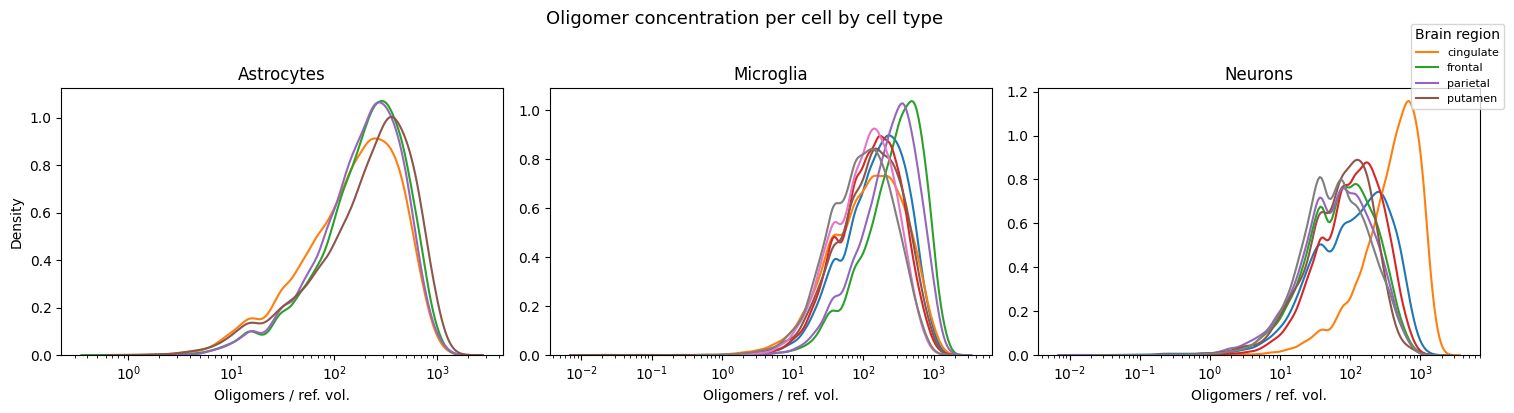

In [4]:
cell_types = sorted(df["cell_type"].unique())
fig, axes = plt.subplots(1, len(cell_types), figsize=(5 * len(cell_types), 4), sharey=False)

for ax, ct in zip(axes, cell_types):
    sub = df_nonzero[df_nonzero["cell_type"] == ct]
    for region in regions:
        data = sub.loc[sub["brain_region"] == region, "oligos_per_ref_vol"]
        if len(data) > 10:
            sns.kdeplot(
                data, ax=ax, label=region, color=palette[region],
                log_scale=True, fill=False, linewidth=1.5
            )
    ax.set_title(ct.capitalize(), fontsize=12)
    ax.set_xlabel("Oligomers / ref. vol.")
    ax.set_ylabel("Density" if ax == axes[0] else "")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Brain region", loc="upper right",
           bbox_to_anchor=(1.01, 1), fontsize=8)
plt.suptitle("Oligomer concentration per cell by cell type", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("oligomer_concentration_by_region_and_celltype.pdf", bbox_inches="tight")
plt.show()

## 3. Oligomer concentration: Male vs Female patients

Violin plot per brain region, split by sex. Each point is a per-patient mean (to avoid pseudoreplication from treating cells as independent).

In [5]:
# Per-patient mean concentration (one value per patient × region × cell_type)
patient_means = (
    df.groupby(["patient_id", "condition", "sex", "brain_region", "cell_type"])
    ["oligos_per_ref_vol"]
    .mean()
    .reset_index()
)

print(patient_means.groupby("sex")["patient_id"].nunique())
patient_means.head()

sex
F     9
M    18
Name: patient_id, dtype: int64


,patient_id,condition,sex,brain_region,cell_type,oligos_per_ref_vol
0,HC1,HC,M,caudate,neurons,501.178368
1,HC1,HC,M,cingulate,astrocytes,498.057212
2,HC1,HC,M,cingulate,microglia,10.967732
3,HC1,HC,M,cingulate,neurons,591.694302
4,HC1,HC,M,frontal,astrocytes,338.053974


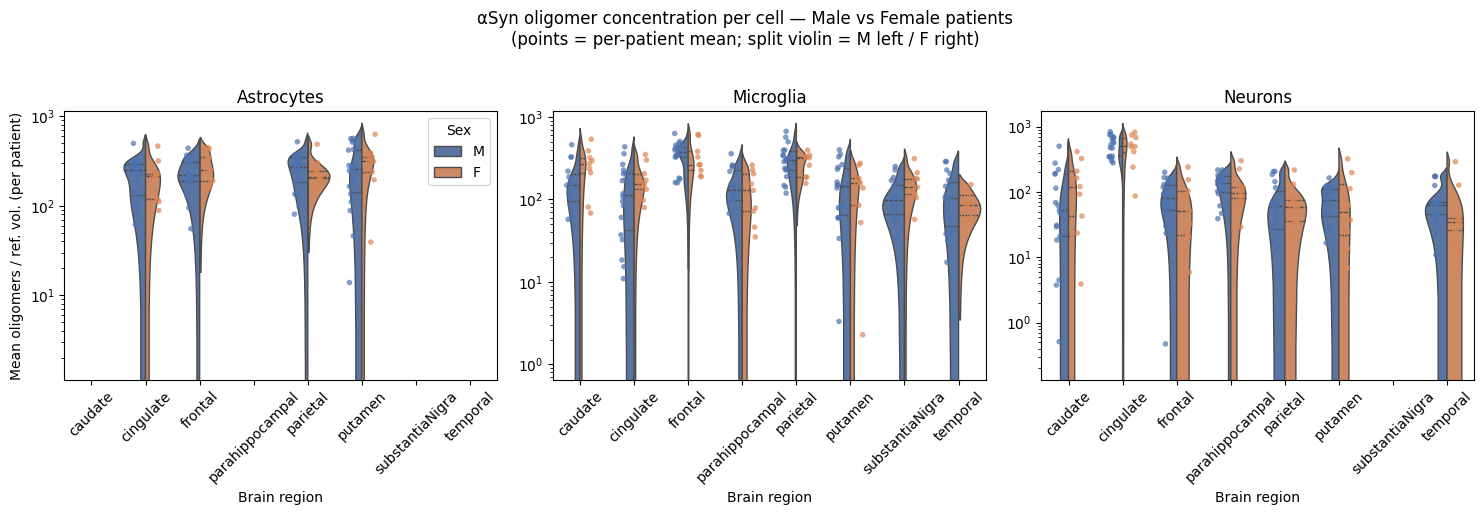

In [6]:
sex_palette = {"M": "#4C72B0", "F": "#DD8452"}

# One subplot per cell type
fig, axes = plt.subplots(1, len(cell_types), figsize=(5 * len(cell_types), 5), sharey=False)

for ax, ct in zip(axes, cell_types):
    sub = patient_means[patient_means["cell_type"] == ct]

    sns.violinplot(
        data=sub, x="brain_region", y="oligos_per_ref_vol",
        hue="sex", palette=sex_palette,
        split=True, inner="quart", linewidth=1,
        order=regions, ax=ax
    )
    sns.stripplot(
        data=sub, x="brain_region", y="oligos_per_ref_vol",
        hue="sex", palette=sex_palette,
        dodge=True, size=4, alpha=0.7, jitter=True,
        order=regions, ax=ax, legend=False
    )

    ax.set_yscale("log")
    ax.set_title(ct.capitalize(), fontsize=12)
    ax.set_xlabel("Brain region")
    ax.set_ylabel("Mean oligomers / ref. vol. (per patient)" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=45)
    if ax != axes[0]:
        ax.get_legend().remove()

axes[0].legend(title="Sex", loc="upper right")
plt.suptitle(
    "αSyn oligomer concentration per cell — Male vs Female patients\n"
    "(points = per-patient mean; split violin = M left / F right)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("oligomer_concentration_sex_by_region.pdf", bbox_inches="tight")
plt.show()

In [ ]:
conn.close()